In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [21]:
df = pd.read_csv(r'..\data\answer_quality_dataset_merge_all.csv')

print(f"Total Data: {df.shape[0]} Baris")
df.head()

Total Data: 3069 Baris


,sample_id,domain,role_family,target_role,competency,question,answer,role_relevance,star_structure,evidence_specificity,...,clarification_type,final_score_0_100,final_score_0_1,quality_label,has_tool,has_metric,has_impact,has_action,has_context,answer_length_words
0,AQD-27DE8C,Information & Technology,Data & AI,Data Analyst,Career Motivation & Fit,"Halo, selamat datang di sesi wawancara. Bisa c...","Ehm... saya... ya, saya sebenarnya... ehh, sek...",25,20,25,...,context,22.75,0.2275,Weak,0,0,0,0,0,101
1,AQD-FBD3C1,Information & Technology,Data & AI,Data Analyst,Career Motivation & Fit,"Halo, selamat datang di sesi wawancara. Bisa c...","Eeeh, halo, Pak/Bu. Selamat siang. Jadi, kalau...",65,45,50,...,metric,59.05,0.5905,Average,1,0,1,1,1,217
2,AQD-6FCBC8,Information & Technology,Data & AI,Data Analyst,Career Motivation & Fit,"Halo, selamat datang di sesi wawancara. Bisa c...","Halo, terima kasih atas kesempatannya. Nama sa...",95,95,95,...,none,93.75,0.9375,Strong,1,1,1,1,1,310
3,AQD-6A3167,Information & Technology,Data & AI,Data Analyst,Career Motivation & Fit,Dari semua project atau materi yang pernah kam...,"Emm... ya, kalo soal yang bikin 'klik' ya... k...",25,0,15,...,context,16.25,0.1625,Weak,1,0,0,1,0,49
4,AQD-46DE80,Information & Technology,Data & AI,Data Analyst,Career Motivation & Fit,Dari semua project atau materi yang pernah kam...,"Ehm, kalau yang bikin saya merasa paling 'klik...",80,55,50,...,contribution,64.0,0.64,Average,0,0,1,1,1,147


In [22]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 12))

<Figure size 1800x1200 with 0 Axes>

<Figure size 1800x1200 with 0 Axes>

C:\Users\nurul\AppData\Local\Temp\ipykernel_3404\1022257376.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='quality_label', palette={'Weak': '#ff9999', 'Average': '#ffcc99', 'Strong': '#99cc99'}, order=['Weak', 'Average', 'Strong'])


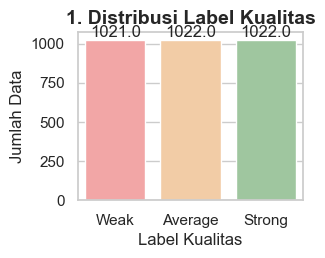

In [23]:
# ==========================================
# PLOT 1: Distribusi Kualitas (Balance Check)
# ==========================================
plt.subplot(2, 2, 1)
ax = sns.countplot(data=df, x='quality_label', palette={'Weak': '#ff9999', 'Average': '#ffcc99', 'Strong': '#99cc99'}, order=['Weak', 'Average', 'Strong'])
plt.title("1. Distribusi Label Kualitas", fontsize=14, fontweight='bold')
plt.xlabel("Label Kualitas")
plt.ylabel("Jumlah Data")
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=12)

C:\Users\nurul\AppData\Local\Temp\ipykernel_3404\2001237520.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality_label', y='answer_length_words', palette={'Weak': '#ff9999', 'Average': '#ffcc99', 'Strong': '#99cc99'}, order=['Weak', 'Average', 'Strong'])


Text(0, 0.5, 'Jumlah Kata')

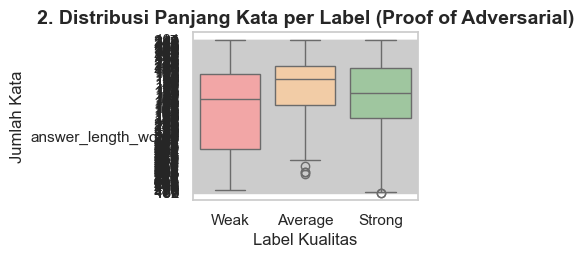

In [24]:
# ==========================================
# PLOT 2: Panjang Kata vs Kualitas 
# ==========================================
# Kalau strategi jebakan kita berhasil, boxplot Weak dan Average harusnya panjang-panjang, 
# dan Strong harusnya banyak yang pendek (Concise Strong).
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='quality_label', y='answer_length_words', palette={'Weak': '#ff9999', 'Average': '#ffcc99', 'Strong': '#99cc99'}, order=['Weak', 'Average', 'Strong'])
plt.title("2. Distribusi Panjang Kata per Label (Proof of Adversarial)", fontsize=14, fontweight='bold')
plt.xlabel("Label Kualitas")
plt.ylabel("Jumlah Kata")

Text(0, 0.5, 'Kepadatan')

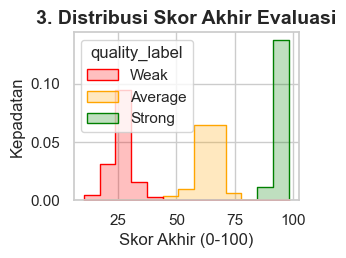

In [25]:
# ==========================================
# PLOT 3: Distribusi Skor Final (Melihat Sebaran 0-100)
# ==========================================
plt.subplot(2, 2, 3)
df['final_score_0_100'] = pd.to_numeric(df['final_score_0_100'], errors='coerce')
sns.histplot(
    data=df,
    x='final_score_0_100',
    hue='quality_label',
    hue_order=['Weak', 'Average', 'Strong'],
    palette=['red', 'orange', 'green'],
    element="step",
    stat="density",
    common_norm=False,
    multiple='layer'
)
plt.title("3. Distribusi Skor Akhir Evaluasi", fontsize=14, fontweight='bold')
plt.xlabel("Skor Akhir (0-100)")
plt.ylabel("Kepadatan")

C:\Users\nurul\AppData\Local\Temp\ipykernel_3404\1083340260.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=metric_stats.index, y=metric_stats.values, palette={'Weak': '#ff9999', 'Average': '#ffcc99', 'Strong': '#99cc99'})


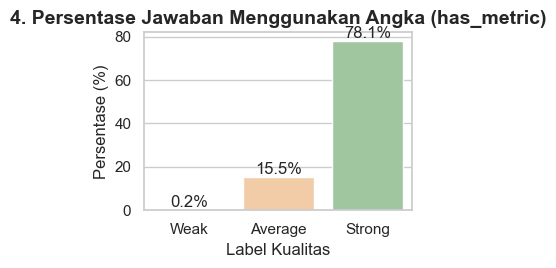

In [26]:
# ==========================================
# PLOT 4: Persentase "Has Metric" Berdasarkan Kualitas
# ==========================================
# Membuktikan bahwa Strong ada yang "No-Number" (has_metric=0) 
# dan Average/Weak ada yang "Misguided Metric" (has_metric=1)
plt.subplot(2, 2, 4)
metric_stats = df.assign(has_metric=pd.to_numeric(df['has_metric'], errors='coerce').fillna(0)).groupby('quality_label')['has_metric'].mean() * 100
metric_stats = metric_stats.reindex(['Weak', 'Average', 'Strong'])
ax2 = sns.barplot(x=metric_stats.index, y=metric_stats.values, palette={'Weak': '#ff9999', 'Average': '#ffcc99', 'Strong': '#99cc99'})
plt.title("4. Persentase Jawaban Menggunakan Angka (has_metric)", fontsize=14, fontweight='bold')
plt.xlabel("Label Kualitas")
plt.ylabel("Persentase (%)")
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

# SPLIT DATA

In [27]:
# --- TAMBAHAN KODE CLEANING ---
# Buang baris "penyusup" (baris yang isinya nama header/kolom)
df = df[df['quality_label'] != 'quality_label']
print(f"Data bersih siap di-split: {len(df)} baris\n")
# ------------------------------

Data bersih siap di-split: 3065 baris



In [28]:
# PEMBAGIAN PERTAMA: Ambil 70% untuk Train, 30% untuk Temp
# stratify=df['quality_label'] memastikan komposisi Weak/Average/Strong tetap adil
train_df, temp_df = train_test_split(
    df, 
    test_size=0.30, 
    random_state=42, # Biar kalau di-run ulang hasilnya gak berubah-ubah
    stratify=df['quality_label']
)

In [29]:
# PEMBAGIAN KEDUA: Bagi Temp (30%) menjadi dua sama rata (15% Val, 15% Test)
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_df['quality_label']
)

In [30]:
# CEK HASIL PEMBAGIAN (Sanity Check)
print("=== HASIL PEMBAGIAN DATA (70% : 15% : 15%) ===")
print(f"Total Data Train : {len(train_df)} baris ({len(train_df)/len(df)*100:.1f}%)")
print(f"Total Data Val   : {len(val_df)} baris ({len(val_df)/len(df)*100:.1f}%)")
print(f"Total Data Test  : {len(test_df)} baris ({len(test_df)/len(df)*100:.1f}%)\n")

print("=== DISTRIBUSI LABEL (Harus Seimbang!) ===")
print("Train Set:\n", train_df['quality_label'].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))
print("\nValidation Set:\n", val_df['quality_label'].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))
print("\nTest Set:\n", test_df['quality_label'].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))

# 5. SIMPAN KE 3 FILE CSV BERBEDA
train_df.to_csv('dataset_train.csv', index=False)
val_df.to_csv('dataset_val.csv', index=False)
test_df.to_csv('dataset_test.csv', index=False)

print("\n[+] Selesai!")

=== HASIL PEMBAGIAN DATA (70% : 15% : 15%) ===
Total Data Train : 2145 baris (70.0%)
Total Data Val   : 460 baris (15.0%)
Total Data Test  : 460 baris (15.0%)

=== DISTRIBUSI LABEL (Harus Seimbang!) ===
Train Set:
 quality_label
Weak       33.3%
Average    33.3%
Strong     33.3%
Name: proportion, dtype: object

Validation Set:
 quality_label
Strong     33.5%
Average    33.3%
Weak       33.3%
Name: proportion, dtype: object

Test Set:
 quality_label
Average    33.5%
Strong     33.3%
Weak       33.3%
Name: proportion, dtype: object



[+] Selesai!
